# Geom Gallery: boxplot, violin, density, tile, hex

This notebook demonstrates five additional geoms beyond the basics
covered in the main ggplot2_py tutorial.

In [1]:
from ggplot2_py import *
from ggplot2_py.plot import GGPlot
from ggplot2_py.datasets import mpg, diamonds
import pandas as pd
import numpy as np

In [2]:
GGPlot.fig_width = 5
GGPlot.fig_height = 4
GGPlot.fig_dpi = 100

## 1. geom_boxplot

Box-and-whisker plots summarise the distribution of a continuous
variable at each level of a categorical variable.

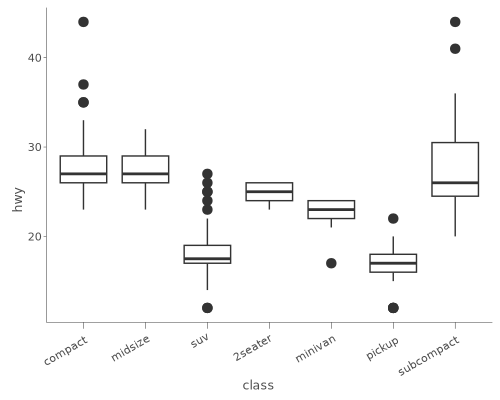

In [3]:
# Basic boxplot
ggplot(mpg, aes(x='class', y='hwy')) + geom_boxplot()

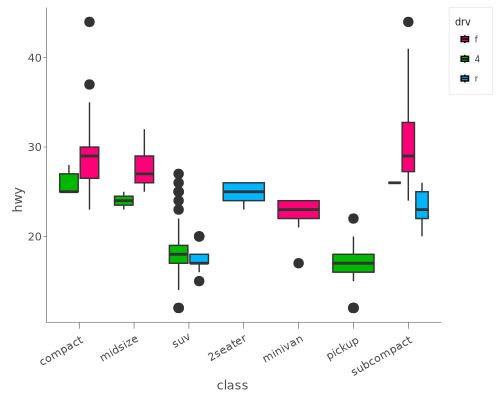

In [4]:
# Filled boxplot with colour by drive train
ggplot(mpg, aes(x='class', y='hwy', fill='drv')) + geom_boxplot()

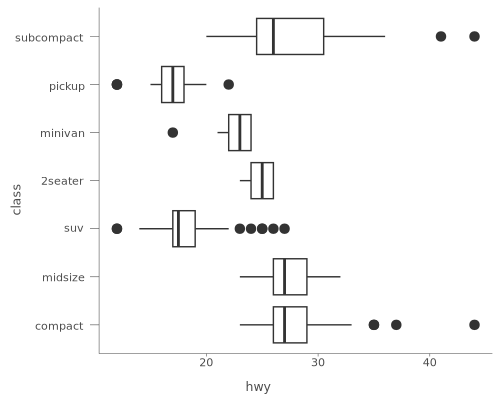

In [5]:
# Horizontal boxplot with coord_flip
ggplot(mpg, aes(x='class', y='hwy')) + geom_boxplot() + coord_flip()

## 2. geom_violin

Violin plots show the kernel density estimate of a distribution,
mirrored around the centre.

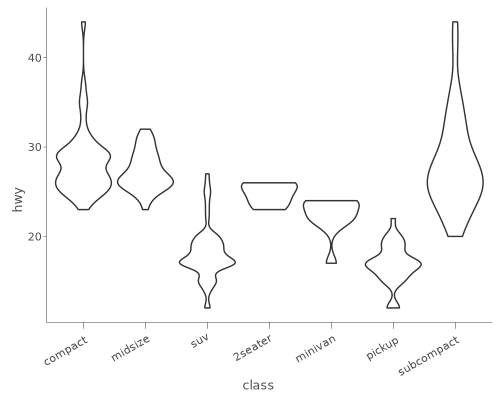

In [6]:
# Basic violin
ggplot(mpg, aes(x='class', y='hwy')) + geom_violin()

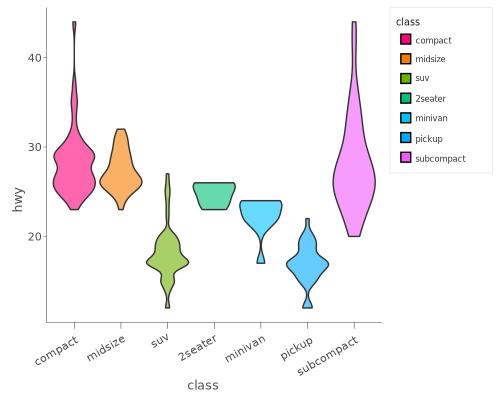

In [7]:
# Filled violin
ggplot(mpg, aes(x='class', y='hwy', fill='class')) + geom_violin(alpha=0.6)

## 3. geom_density

Density plots display a smoothed estimate of the distribution
of a continuous variable.

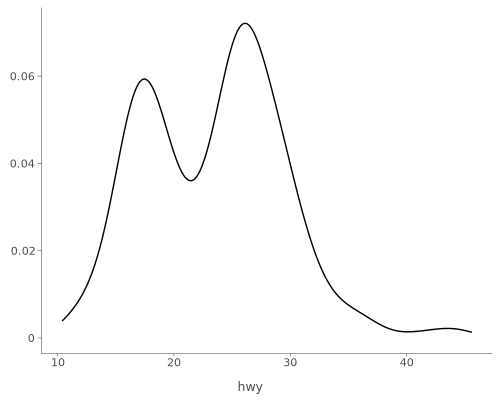

In [8]:
# Single density curve
ggplot(mpg, aes(x='hwy')) + geom_density()

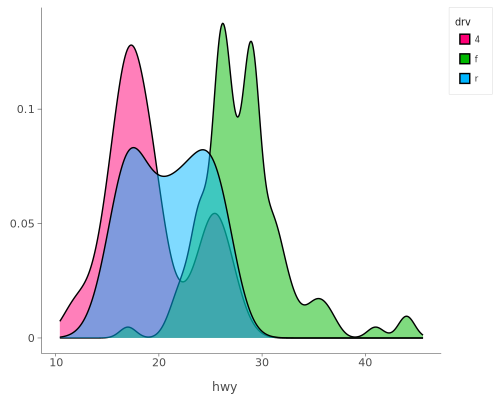

In [9]:
# Overlapping densities by group
ggplot(mpg, aes(x='hwy', fill='drv')) + geom_density(alpha=0.5)

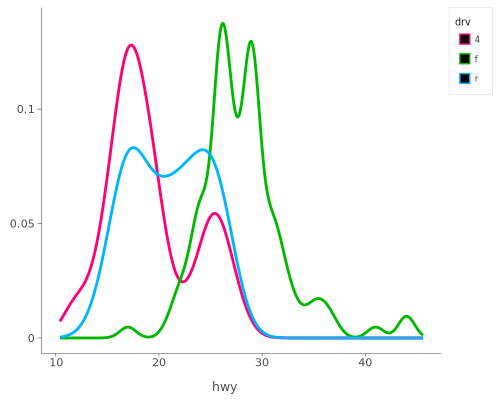

In [10]:
# Density with colour outline only
ggplot(mpg, aes(x='hwy', colour='drv')) + geom_density(linewidth=1)

## 4. geom_tile

Tile plots (heatmaps) fill rectangles at specified positions,
useful for 2-D binned data or correlation matrices.

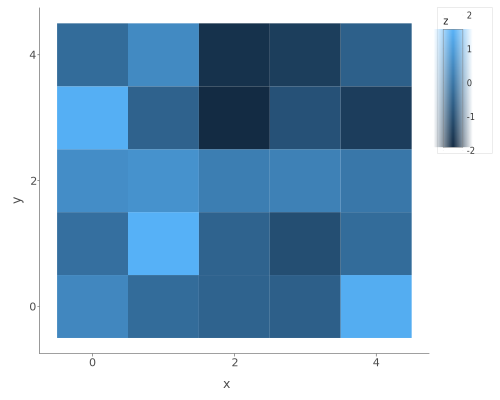

In [11]:
# Simple 5x5 heatmap
np.random.seed(42)
tile_data = pd.DataFrame({
    'x': np.repeat(range(5), 5),
    'y': np.tile(range(5), 5),
    'z': np.random.randn(25),
})
ggplot(tile_data, aes('x', 'y', fill='z')) + geom_tile()

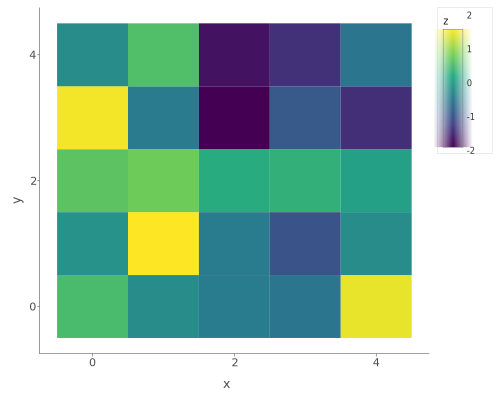

In [12]:
# Tile with viridis colour scale
ggplot(tile_data, aes('x', 'y', fill='z')) + geom_tile() + scale_fill_viridis_c()

## 5. geom_hex

Hexagonal binning is an alternative to `geom_bin2d` for
two-dimensional histograms, reducing visual artefacts from
rectangular bins.

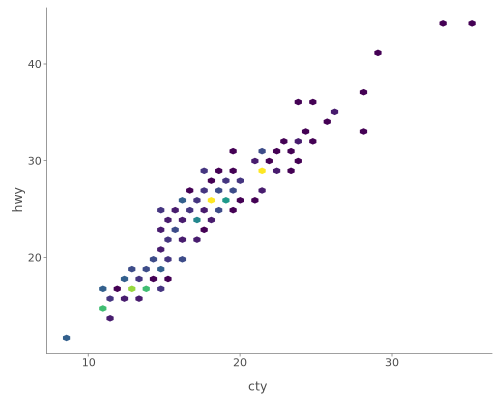

In [13]:
# Hexagonal binning
ggplot(mpg, aes(x='cty', y='hwy')) + geom_hex()

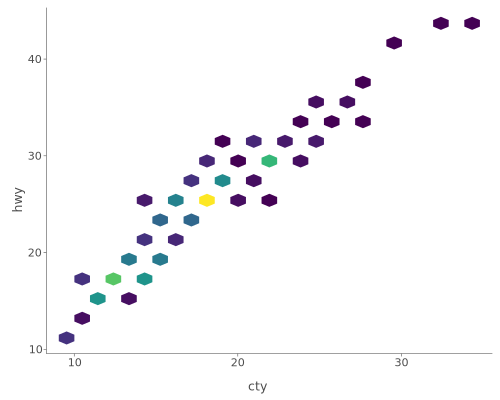

In [14]:
# Hex with fewer bins
ggplot(mpg, aes(x='cty', y='hwy')) + geom_hex(bins=15)

## 6. Combining geoms

Geoms can be layered for richer visualisations.

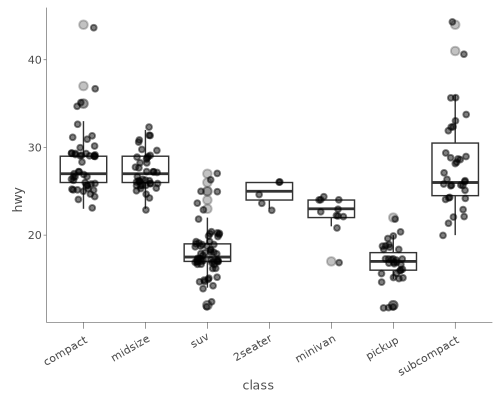

In [15]:
# Boxplot + jittered points
(
    ggplot(mpg, aes(x='class', y='hwy'))
    + geom_boxplot(alpha=0.3)
    + geom_jitter(width=0.2, size=0.8, alpha=0.5)
)

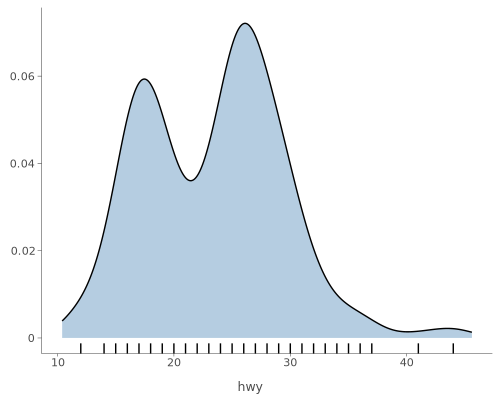

In [16]:
# Density + rug marks
ggplot(mpg, aes(x='hwy')) + geom_density(fill='steelblue', alpha=0.4) + geom_rug()

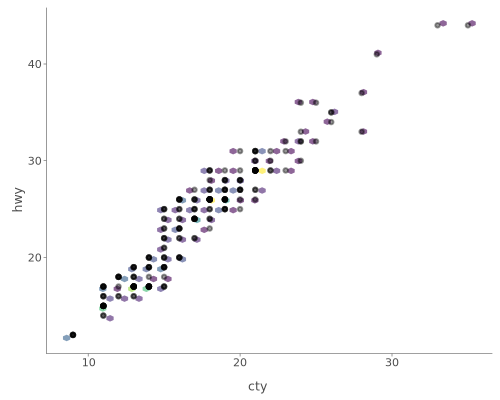

In [17]:
# Scatter + hex overlay
(
    ggplot(mpg, aes(x='cty', y='hwy'))
    + geom_hex(alpha=0.6)
    + geom_point(size=0.5, alpha=0.4)
)